ARTI308 - Machine Learning
# Seaborn Overview

Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics.




## Distribution Plots

Let's discuss some plots that allow us to visualize the distribution of a data set. These plots are:

* distplot
* jointplot
* pairplot
* rugplot
* kdeplot

## Imports

In [1]:
# Import Seaborn (statistical data visualization) and enable inline plot display in Jupyter
import seaborn as sns 
%matplotlib inline    

## Data
Seaborn comes with built-in data sets!

In [2]:
# Load built-in tips dataset (restaurant tipping data) - no download needed
tips = sns.load_dataset('tips')

In [3]:
# Display first 5 rows to inspect the dataset structure
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## distplot

The distplot shows the distribution of a univariate set of observations.

/var/folders/22/_5dpfqbs0bxb06d4ljk5bcmh0000gn/T/ipykernel_25184/268005664.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tips['total_bill'])


<Axes: xlabel='total_bill', ylabel='Density'>

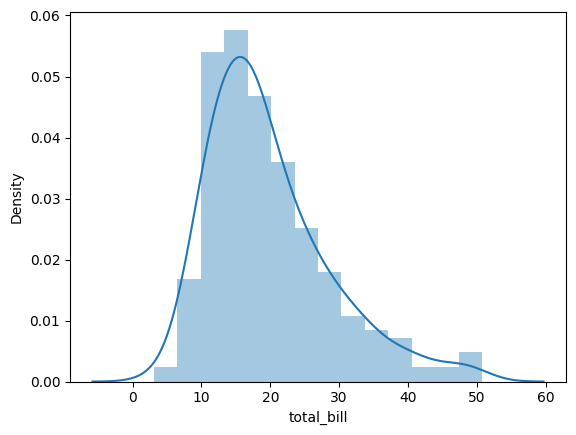

In [4]:
# distplot (deprecated): histogram + KDE - shows distribution of total_bill (use histplot for new code)
sns.distplot(tips['total_bill'])
# Safe to ignore warnings

To remove the kde layer and just have the histogram use:

<Axes: xlabel='total_bill', ylabel='Count'>

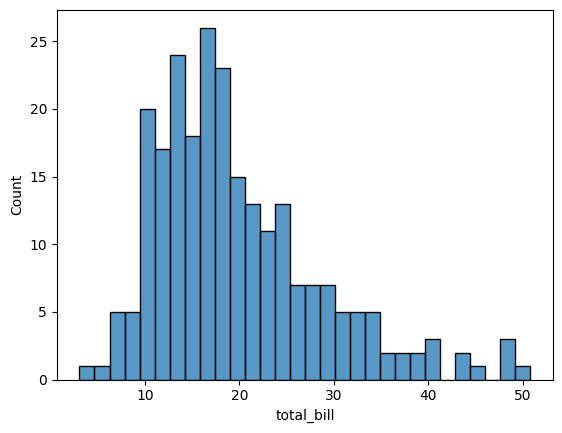

In [5]:
# Histogram without KDE: only bars, 30 bins for finer granularity
sns.histplot(tips['total_bill'], kde=False, bins=30)

## jointplot

jointplot() allows you to basically match up two distplots for bivariate data. With your choice of what **kind** parameter to compare with: 
* “scatter” 
* “reg” 
* “resid” 
* “kde” 
* “hex”

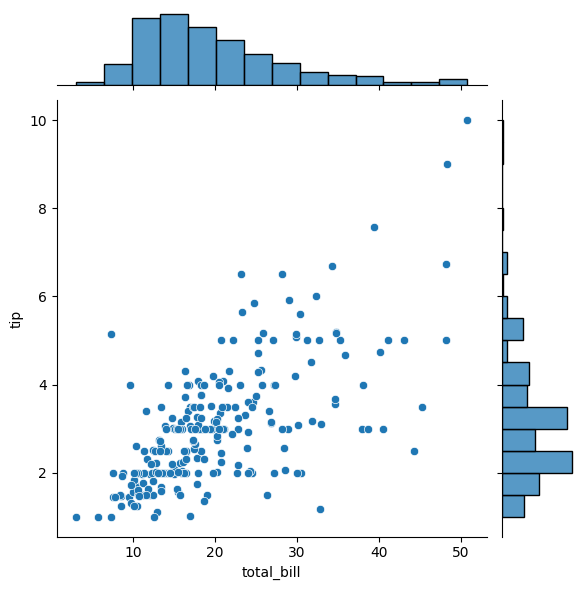

In [6]:
# Joint plot: bivariate analysis - scatter plot with marginal distributions (histograms)
sns.jointplot(x='total_bill',y='tip',data=tips,kind='scatter')

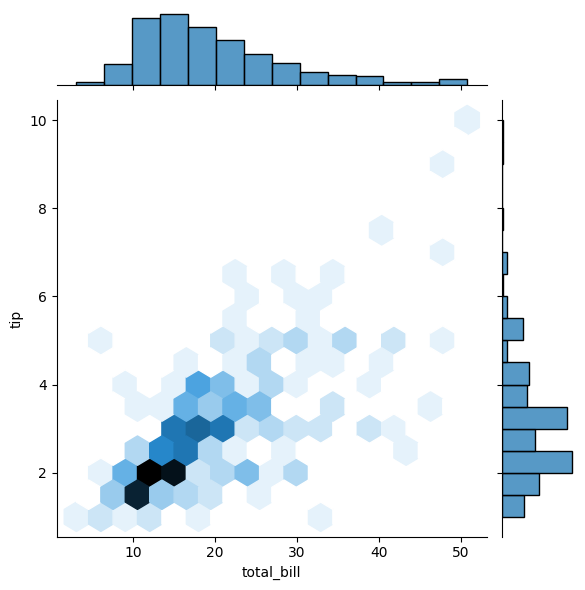

In [7]:
# Hexbin joint plot: 2D histogram with hexagons - better for dense data
sns.jointplot(x='total_bill',y='tip',data=tips,kind='hex')

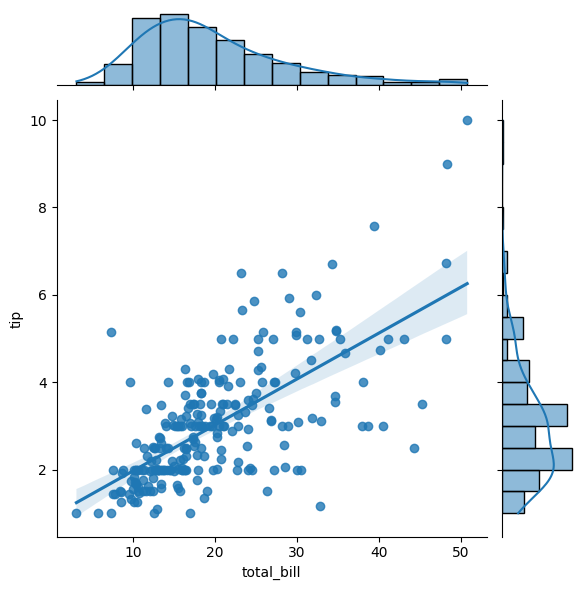

In [8]:
# Regression joint plot: scatter + regression line + confidence interval
sns.jointplot(x='total_bill',y='tip',data=tips,kind='reg')

## pairplot

pairplot will plot pairwise relationships across an entire dataframe (for the numerical columns) and supports a color hue argument (for categorical columns). 

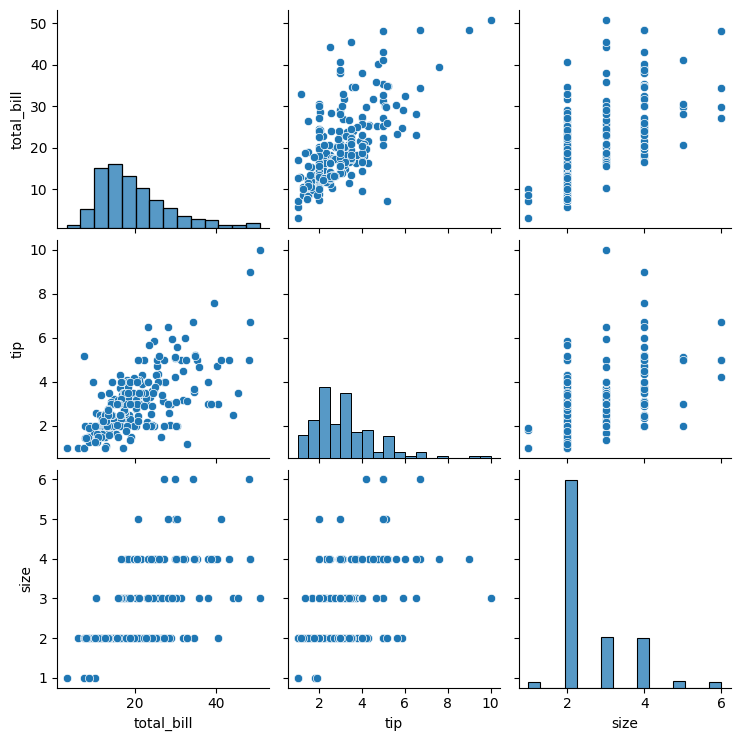

In [9]:
# Pairplot: all pairwise relationships between numeric columns (scatter matrix)
sns.pairplot(tips)

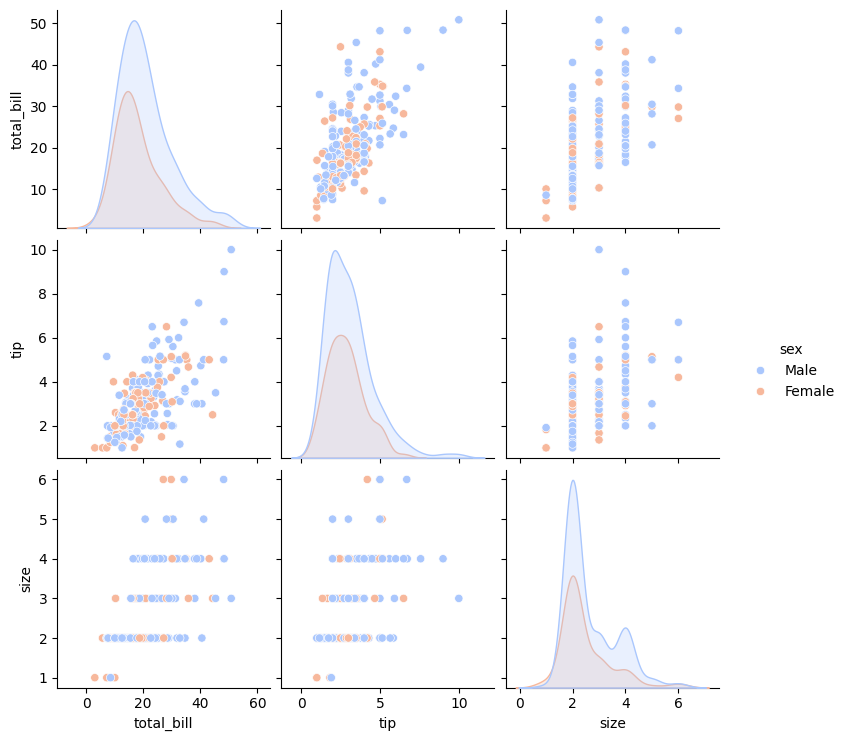

In [10]:
# Pairplot with hue: color points by categorical variable (sex) using coolwarm palette
sns.pairplot(tips,hue='sex',palette='coolwarm')

## rugplot

rugplots are actually a very simple concept, they just draw a dash mark for every point on a univariate distribution. They are the building block of a KDE plot:

<Axes: xlabel='total_bill'>

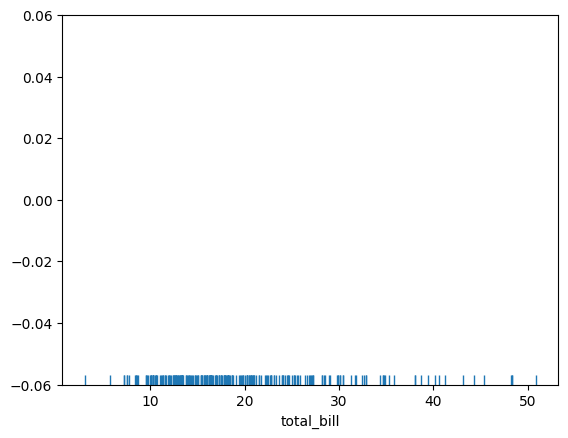

In [11]:
# Rug plot: tick marks along axis showing data density (1D distribution)
sns.rugplot(tips['total_bill'])

## kdeplot

kdeplots are [Kernel Density Estimation plots](http://en.wikipedia.org/wiki/Kernel_density_estimation#Practical_estimation_of_the_bandwidth). These KDE plots replace every single observation with a Gaussian (Normal) distribution centered around that value. For example:

(0.0, 1.0)

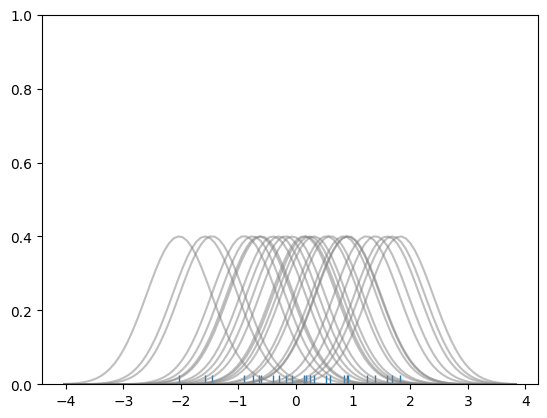

In [12]:
# KDE diagram: demonstrates how kernel density estimation works (basis functions + rug)
# It's just for the diagram below
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

#Create dataset
dataset = np.random.randn(25)

# Create another rugplot
sns.rugplot(dataset);

# Set up the x-axis for the plot
x_min = dataset.min() - 2
x_max = dataset.max() + 2

# 100 equally spaced points from x_min to x_max
x_axis = np.linspace(x_min,x_max,100)

# Set up the bandwidth, for info on this:
url = 'http://en.wikipedia.org/wiki/Kernel_density_estimation#Practical_estimation_of_the_bandwidth'

bandwidth = ((4*dataset.std()**5)/(3*len(dataset)))**.2


# Create an empty kernel list
kernel_list = []

# Plot each basis function
for data_point in dataset:
    
    # Create a kernel for each point and append to list
    kernel = stats.norm(data_point,bandwidth).pdf(x_axis)
    kernel_list.append(kernel)
    
    #Scale for plotting
    kernel = kernel / kernel.max()
    kernel = kernel * .4
    plt.plot(x_axis,kernel,color = 'grey',alpha=0.5)

plt.ylim(0,1)

Text(0.5, 0.98, 'Sum of the Basis Functions')

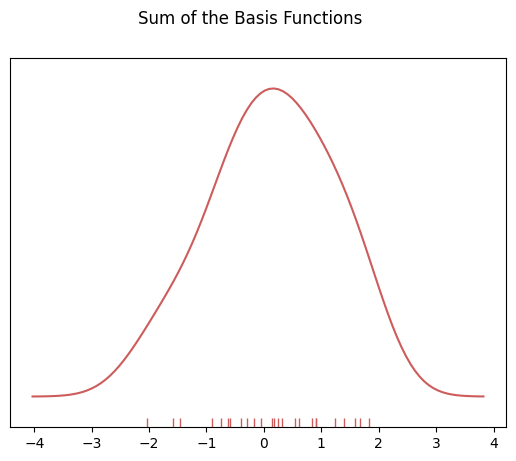

In [13]:
# To get the kde plot we can sum these basis functions.

# Plot the sum of the basis function
sum_of_kde = np.sum(kernel_list,axis=0)

# Plot figure
fig = plt.plot(x_axis,sum_of_kde,color='indianred')

# Add the initial rugplot
sns.rugplot(dataset,c = 'indianred')

# Get rid of y-tick marks
plt.yticks([])

# Set title
plt.suptitle("Sum of the Basis Functions")

So with our tips dataset:

<Axes: xlabel='total_bill', ylabel='Density'>

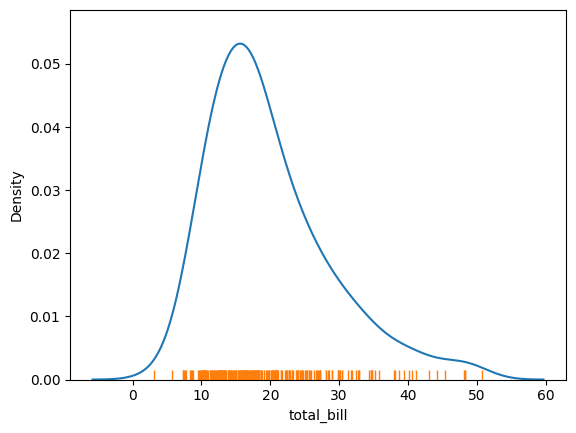

In [14]:
# KDE plot: smooth density estimate; rugplot adds tick marks at data points
sns.kdeplot(tips['total_bill'])
sns.rugplot(tips['total_bill'])

<Axes: xlabel='tip', ylabel='Density'>

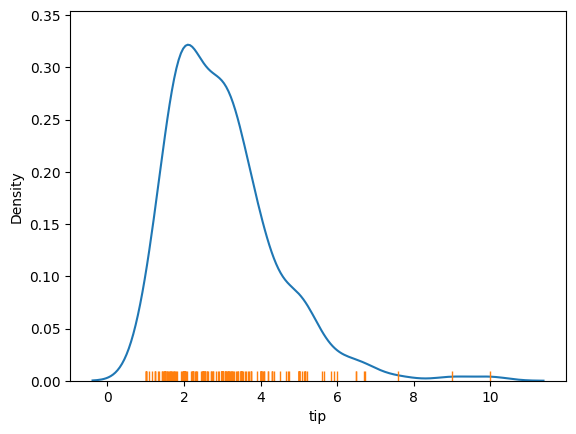

In [15]:
# Same KDE + rug for tip variable - shows distribution of tip amounts
sns.kdeplot(tips['tip'])
sns.rugplot(tips['tip'])

# Categorical Data Plots

Now let's discuss using seaborn to plot categorical data! There are a few main plot types for this:

* factorplot
* boxplot
* violinplot
* stripplot
* swarmplot
* barplot
* countplot

Let's go through examples of each!

In [16]:
import seaborn as sns
%matplotlib inline

In [17]:
# Load tips and peek - Categorical Plots section uses same dataset
tips = sns.load_dataset('tips')
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## barplot and countplot

These very similar plots allow you to get aggregate data off a categorical feature in your data. **barplot** is a general plot that allows you to aggregate the categorical data based off some function, by default the mean:

<Axes: xlabel='sex', ylabel='total_bill'>

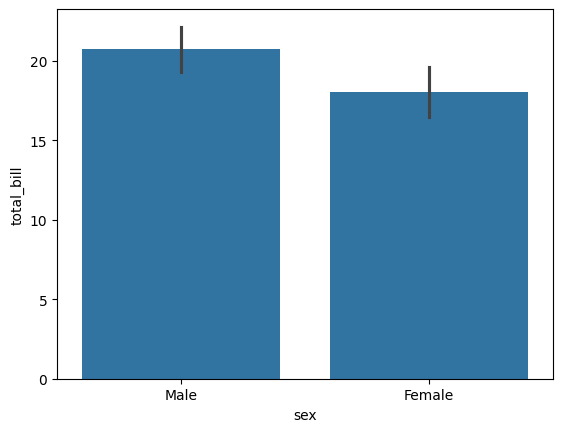

In [18]:
# Bar plot: categorical (sex) vs numeric (total_bill); shows mean by default
sns.barplot(x='sex',y='total_bill',data=tips)

In [19]:
# NumPy needed for custom estimators (e.g. np.std)
import numpy as np

You can change the estimator object to your own function, that converts a vector to a scalar:

<Axes: xlabel='sex', ylabel='total_bill'>

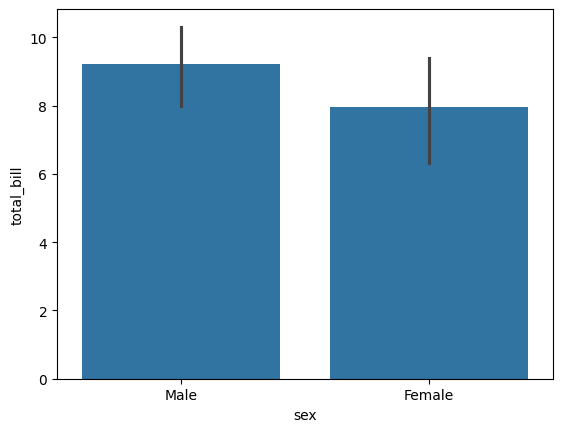

In [20]:
# Bar plot with custom estimator: std instead of mean (shows variability)
sns.barplot(x='sex',y='total_bill',data=tips,estimator=np.std)

### countplot

This is essentially the same as barplot except the estimator is explicitly counting the number of occurrences. Which is why we only pass the x value:

<Axes: xlabel='sex', ylabel='count'>

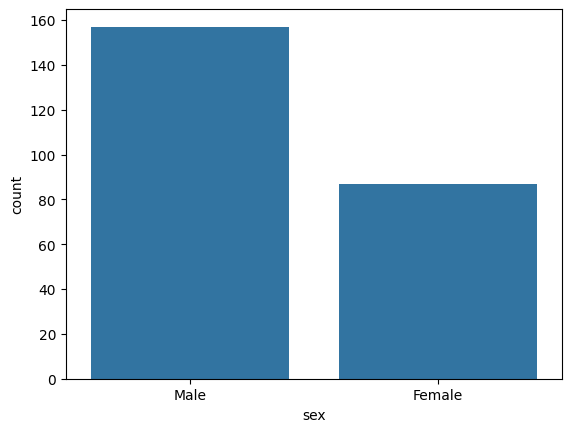

In [21]:
# Count plot: counts occurrences of each category (like bar chart of value_counts)
sns.countplot(x='sex',data=tips)

## boxplot and violinplot

boxplots and violinplots are used to shown the distribution of categorical data. A box plot (or box-and-whisker plot) shows the distribution of quantitative data in a way that facilitates comparisons between variables or across levels of a categorical variable. The box shows the quartiles of the dataset while the whiskers extend to show the rest of the distribution, except for points that are determined to be “outliers” using a method that is a function of the inter-quartile range.

/var/folders/22/_5dpfqbs0bxb06d4ljk5bcmh0000gn/T/ipykernel_25184/4027360087.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="day", y="total_bill", data=tips,palette='rainbow')


<Axes: xlabel='day', ylabel='total_bill'>

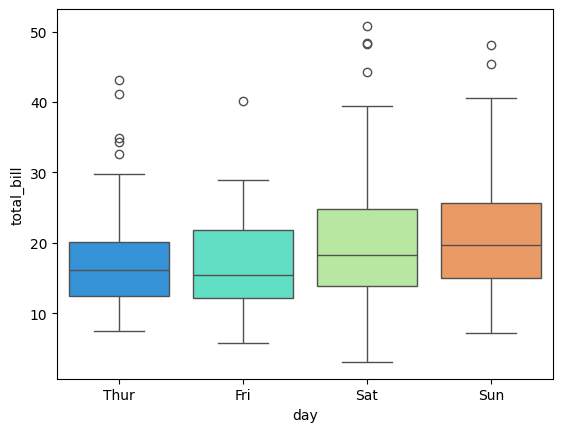

In [22]:
# Box plot: quartiles, median, outliers - compare total_bill across days
sns.boxplot(x="day", y="total_bill", data=tips,palette='rainbow')

<Axes: >

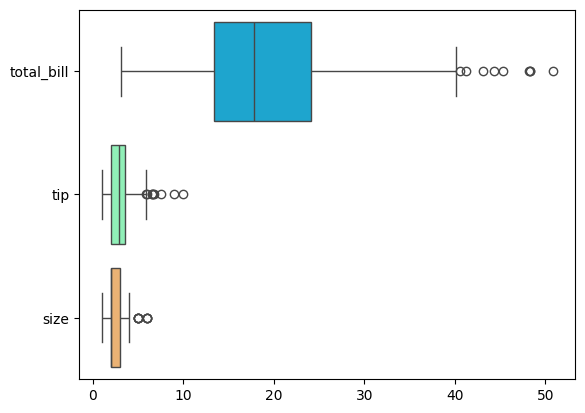

In [23]:
# Horizontal box plot for entire dataframe - one box per numeric column
sns.boxplot(data=tips,palette='rainbow',orient='h')

<Axes: xlabel='day', ylabel='total_bill'>

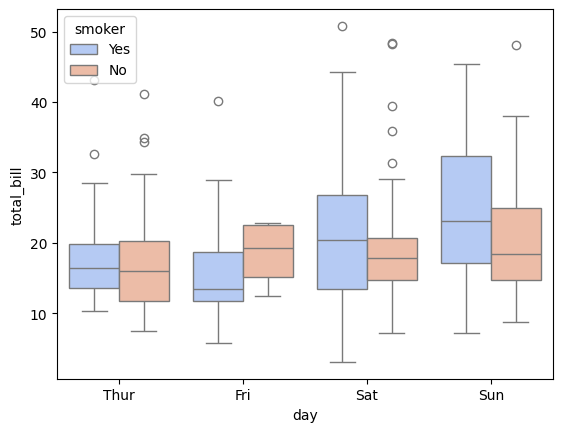

In [24]:
# Box plot with hue: split by smoker - compare smokers vs non-smokers per day
sns.boxplot(x="day", y="total_bill", hue="smoker",data=tips, palette="coolwarm")

### violinplot
A violin plot plays a similar role as a box and whisker plot. It shows the distribution of quantitative data across several levels of one (or more) categorical variables such that those distributions can be compared. Unlike a box plot, in which all of the plot components correspond to actual datapoints, the violin plot features a kernel density estimation of the underlying distribution.

/var/folders/22/_5dpfqbs0bxb06d4ljk5bcmh0000gn/T/ipykernel_25184/2615133164.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="day", y="total_bill", data=tips,palette='rainbow')


<Axes: xlabel='day', ylabel='total_bill'>

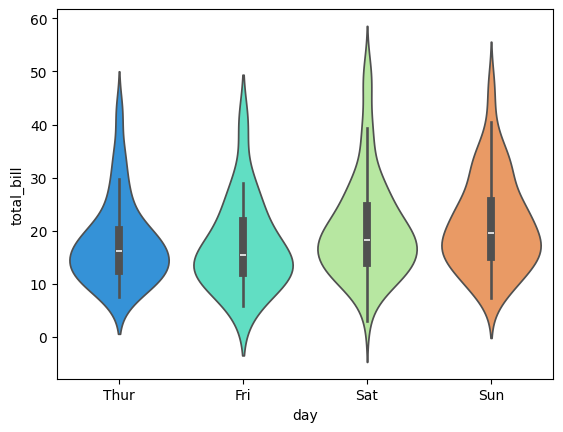

In [25]:
# Violin plot: like box plot but shows full distribution shape (KDE)
sns.violinplot(x="day", y="total_bill", data=tips,palette='rainbow')

<Axes: xlabel='day', ylabel='total_bill'>

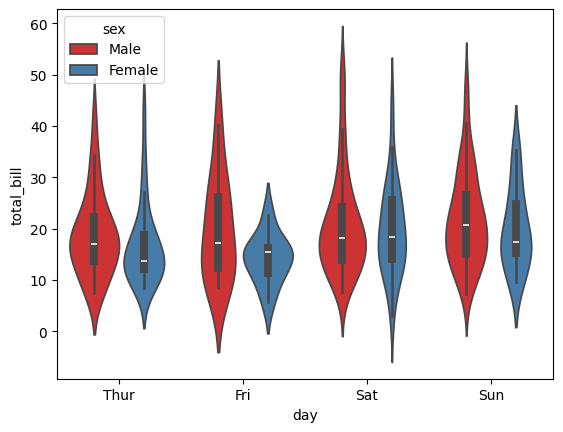

In [26]:
# Violin with hue: split by sex - compare male vs female distributions
sns.violinplot(x="day", y="total_bill", data=tips,hue='sex',palette='Set1')

<Axes: xlabel='day', ylabel='total_bill'>

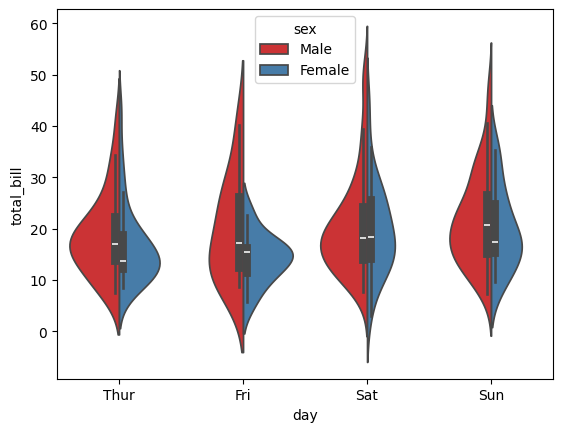

In [27]:
# Violin with split=True: male and female on same violin (half each) for direct comparison
sns.violinplot(x="day", y="total_bill", data=tips,hue='sex',split=True,palette='Set1')

## stripplot and swarmplot
The stripplot will draw a scatterplot where one variable is categorical. A strip plot can be drawn on its own, but it is also a good complement to a box or violin plot in cases where you want to show all observations along with some representation of the underlying distribution.

The swarmplot is similar to stripplot(), but the points are adjusted (only along the categorical axis) so that they don’t overlap. This gives a better representation of the distribution of values, although it does not scale as well to large numbers of observations (both in terms of the ability to show all the points and in terms of the computation needed to arrange them).

/var/folders/22/_5dpfqbs0bxb06d4ljk5bcmh0000gn/T/ipykernel_25184/2718098369.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x="day", y="total_bill", data=tips, palette='rainbow')


<Axes: xlabel='day', ylabel='total_bill'>

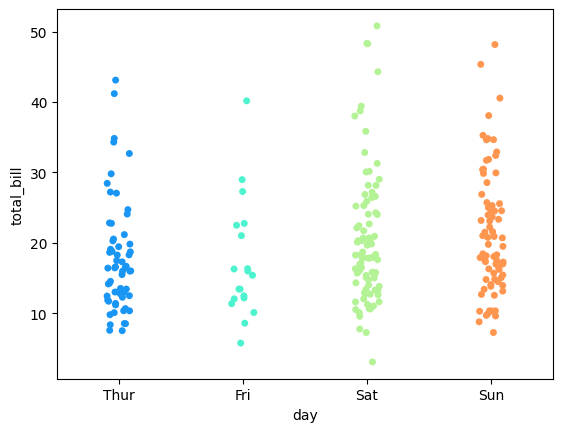

In [28]:
# Strip plot: scatter where one variable is categorical - points may overlap
sns.stripplot(x="day", y="total_bill", data=tips, palette='rainbow')

/var/folders/22/_5dpfqbs0bxb06d4ljk5bcmh0000gn/T/ipykernel_25184/9260894.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x="day", y="total_bill", data=tips,jitter=True, palette='rainbow')


<Axes: xlabel='day', ylabel='total_bill'>

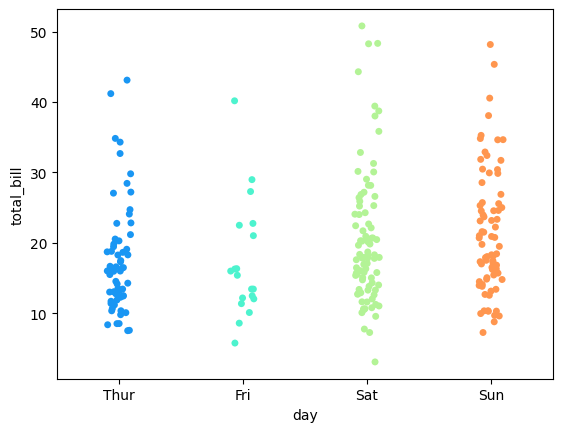

In [29]:
# Jitter=True: adds random horizontal spread to reduce overlapping points
sns.stripplot(x="day", y="total_bill", data=tips,jitter=True, palette='rainbow')

<Axes: xlabel='day', ylabel='total_bill'>

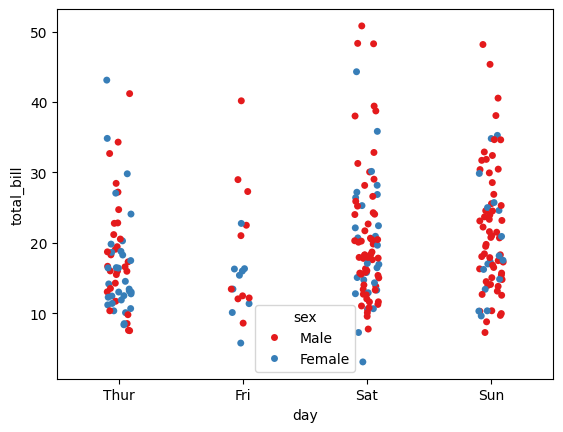

In [30]:
# Strip with hue: color by sex - compare male vs female points
sns.stripplot(x="day", y="total_bill", data=tips,jitter=True,hue='sex',palette='Set1')

<Axes: xlabel='day', ylabel='total_bill'>

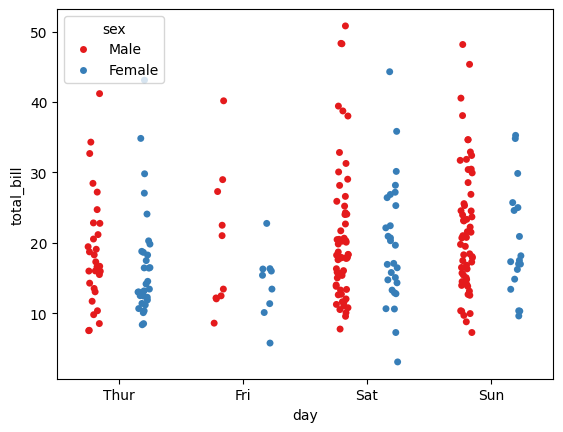

In [31]:
# dodge=True: separate strips for each hue so male/female don't overlap
sns.stripplot(x="day", y="total_bill", data=tips,jitter=True,hue='sex',palette='Set1',dodge=True)

<Axes: xlabel='day', ylabel='total_bill'>

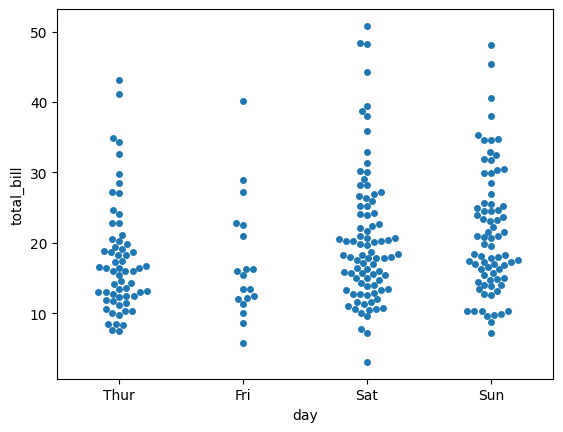

In [32]:
# Swarm plot: like strip but points adjusted to avoid overlap (beeswarm style)
sns.swarmplot(x="day", y="total_bill", data=tips)

### Combining Categorical Plots

/var/folders/22/_5dpfqbs0bxb06d4ljk5bcmh0000gn/T/ipykernel_25184/3787758532.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="tip", y="day", data=tips,palette='rainbow')


<Axes: xlabel='tip', ylabel='day'>

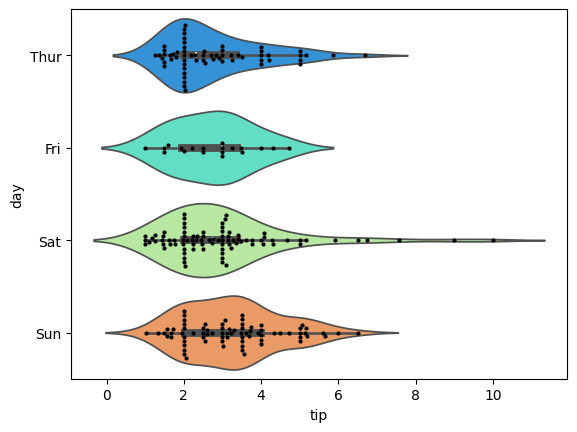

In [33]:
# Combining plots: violin as background + swarm overlay - shows distribution and individual points
sns.violinplot(x="tip", y="day", data=tips,palette='rainbow')
sns.swarmplot(x="tip", y="day", data=tips,color='black',size=3)

## catplot

factorplot is the most general form of a categorical plot. It can take in a kind parameter to adjust the plot type:

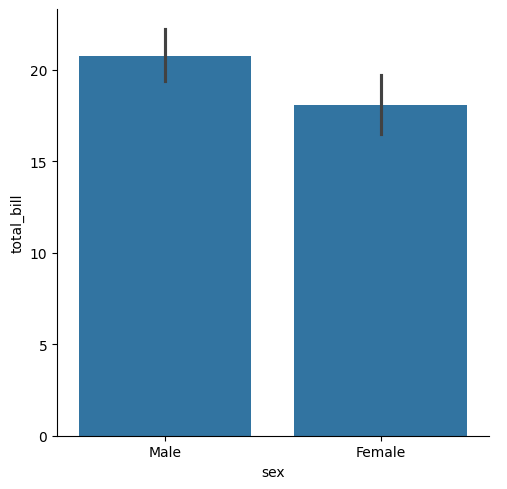

In [34]:
# catplot: general categorical plot - kind='bar' creates bar plot (figure-level, uses facets)
sns.catplot(x='sex',y='total_bill',data=tips,kind='bar')

# Matrix Plots

Matrix plots allow you to plot data as color-encoded matrices and can also be used to indicate clusters within the data (later in the machine learning section we will learn how to formally cluster data).

Let's begin by exploring seaborn's heatmap and clutermap:

In [35]:
import seaborn as sns
%matplotlib inline

In [36]:
# Load flights dataset - airline passenger numbers by month/year (for heatmap)
flights = sns.load_dataset('flights')

In [37]:
tips = sns.load_dataset('tips')

In [38]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [39]:
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


## Heatmap

In order for a heatmap to work properly, your data should already be in a matrix form, the sns.heatmap function basically just colors it in for you. For example:

In [40]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [41]:
# Correlation matrix: shows pairwise correlations between numeric columns only
tips.corr(numeric_only=True)

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


<Axes: >

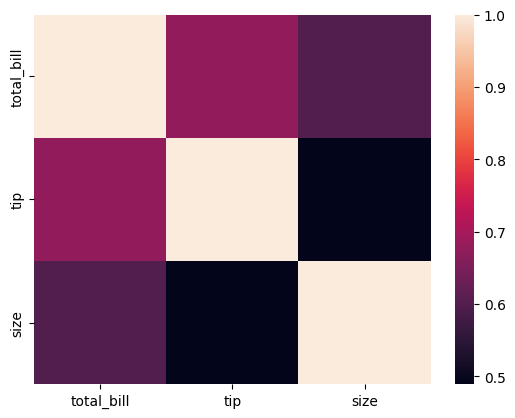

In [42]:
# Heatmap: color-encoded matrix - correlation values as colors (darker = stronger)
sns.heatmap(tips.corr(numeric_only=True))

<Axes: >

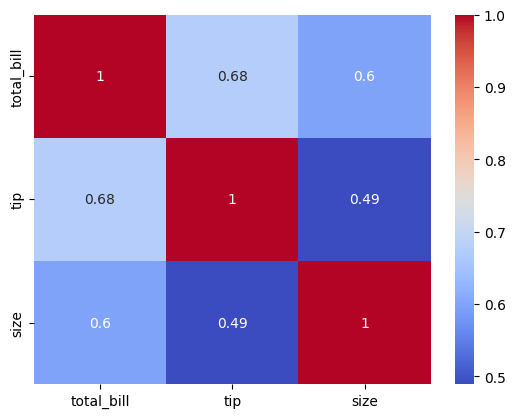

In [43]:
# Heatmap with annot=True: show actual values in cells; coolwarm colormap (blue-red)
sns.heatmap(tips.corr(numeric_only=True), cmap='coolwarm', annot=True)

Or for the flights data:

In [44]:
# Pivot: reshape to matrix form (rows=month, cols=year, values=passengers) for heatmap
pvflights = flights.pivot_table(values='passengers',index='month',columns='year')

/var/folders/22/_5dpfqbs0bxb06d4ljk5bcmh0000gn/T/ipykernel_25184/2233860586.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pvflights = flights.pivot_table(values='passengers',index='month',columns='year')


<Axes: xlabel='year', ylabel='month'>

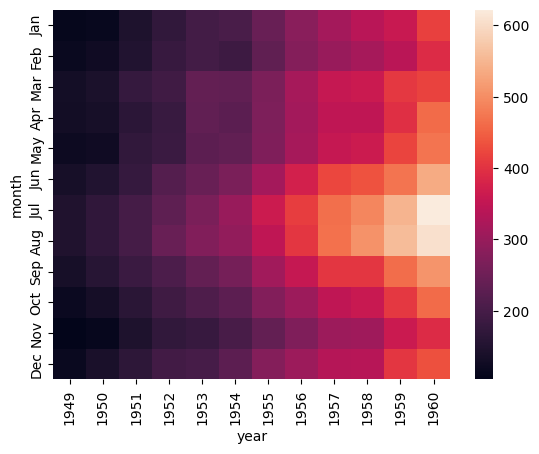

In [45]:
sns.heatmap(pvflights)

<Axes: xlabel='year', ylabel='month'>

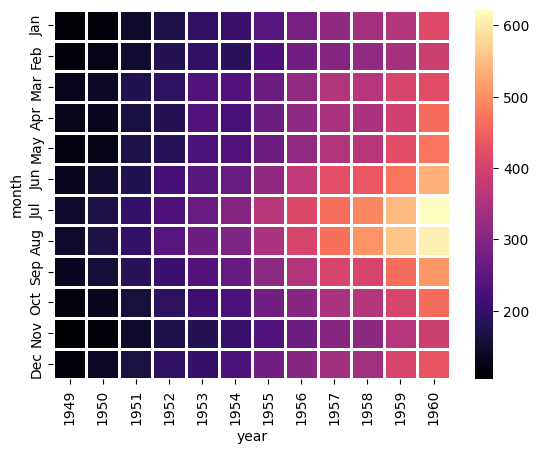

In [46]:
# Heatmap styling: magma colormap, white grid lines between cells
sns.heatmap(pvflights,cmap='magma',linecolor='white',linewidths=1)

## clustermap

The clustermap uses hierarchal clustering to produce a clustered version of the heatmap. For example:

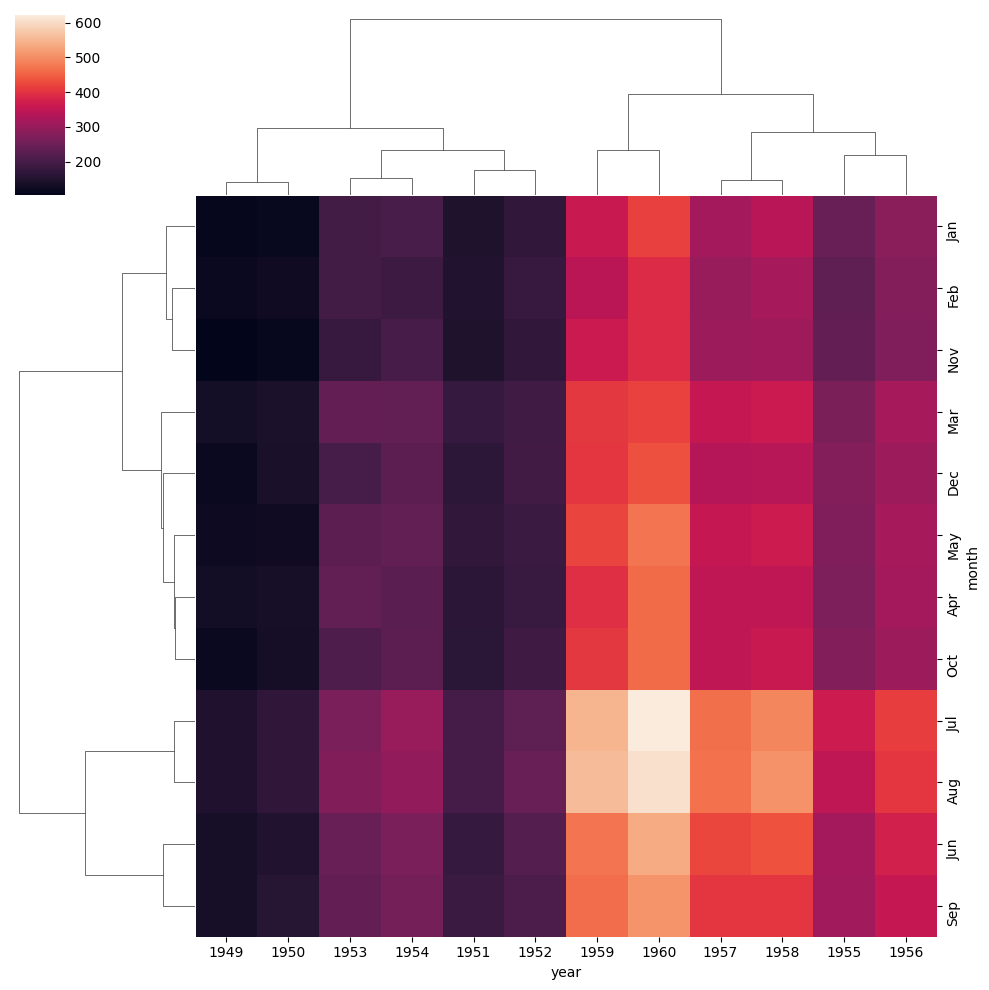

In [47]:
# Clustermap: heatmap + hierarchical clustering - reorders rows/cols by similarity
sns.clustermap(pvflights)

Notice now how the years and months are no longer in order, instead they are grouped by similarity in value (passenger count). That means we can begin to infer things from this plot, such as August and July being similar (makes sense, since they are both summer travel months)

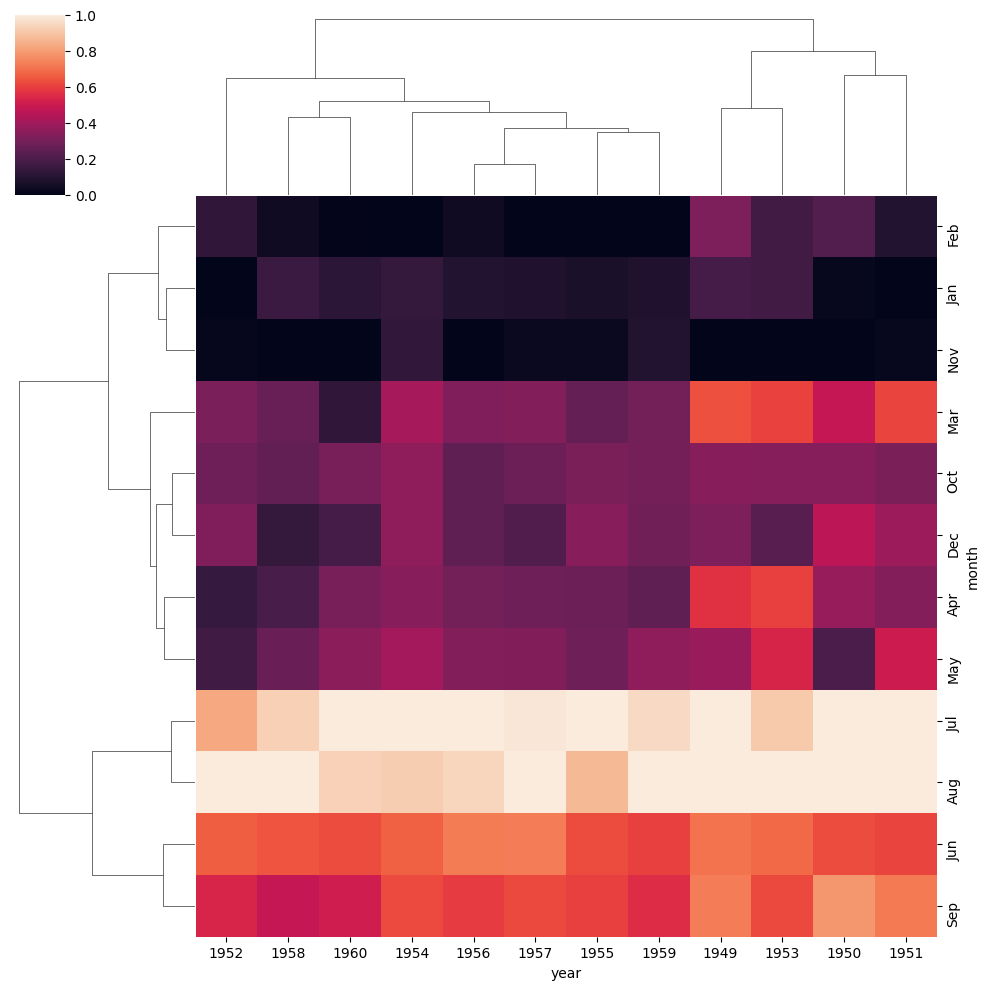

In [48]:
# standard_scale=1: normalize each column (0-1) for clearer pattern comparison
sns.clustermap(pvflights,standard_scale=1)

# Regression Plots

Seaborn has many built-in capabilities for regression plots, however we won't really discuss regression until the machine learning section of the course, so we will only cover the **lmplot()** function for now.

**lmplot** allows you to display linear models, but it also conveniently allows you to split up those plots based off of features, as well as coloring the hue based off of features.

Let's explore how this works:

In [49]:
import seaborn as sns
%matplotlib inline

In [50]:
tips = sns.load_dataset('tips')

In [51]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## lmplot()

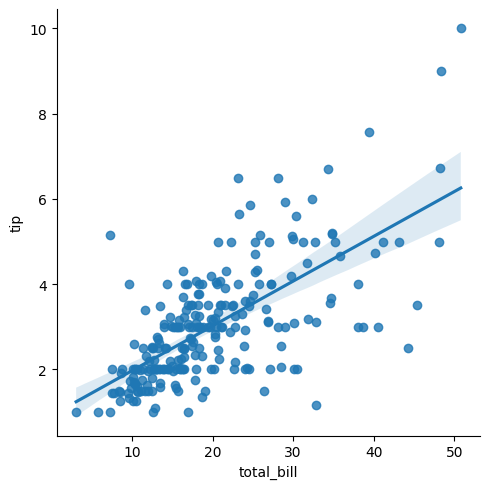

In [52]:
# lmplot: scatter + linear regression line + confidence interval (relationship between variables)
sns.lmplot(x='total_bill',y='tip',data=tips)

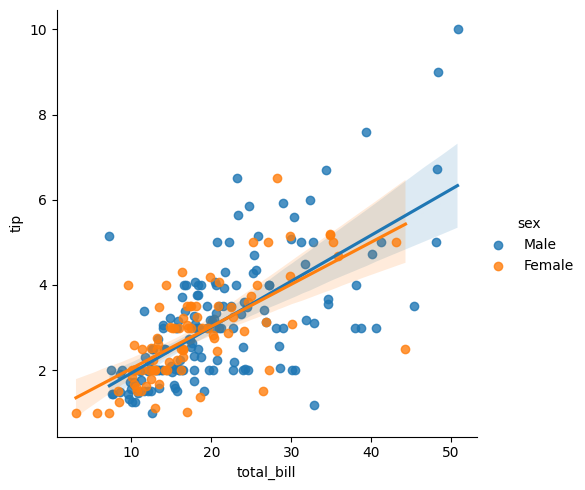

In [53]:
# lmplot with hue: separate regression lines colored by sex
sns.lmplot(x='total_bill',y='tip',data=tips,hue='sex')

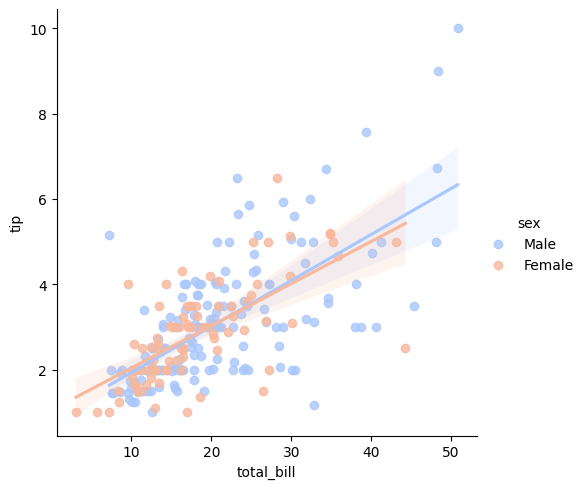

In [54]:
sns.lmplot(x='total_bill',y='tip',data=tips,hue='sex',palette='coolwarm')

## Using a Grid

We can add more variable separation through columns and rows with the use of a grid. Just indicate this with the col or row arguments:

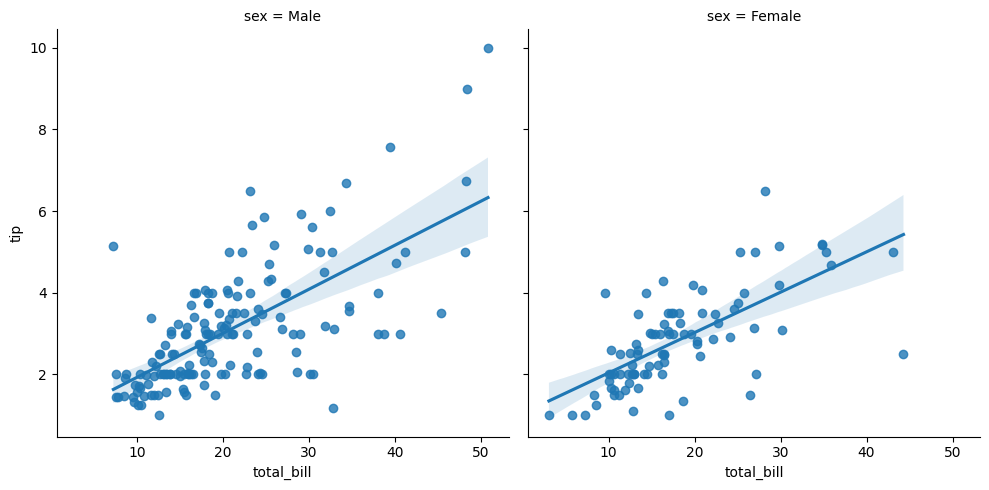

In [55]:
# col='sex': creates separate subplots (facets) for each sex - side by side comparison
sns.lmplot(x='total_bill',y='tip',data=tips,col='sex')

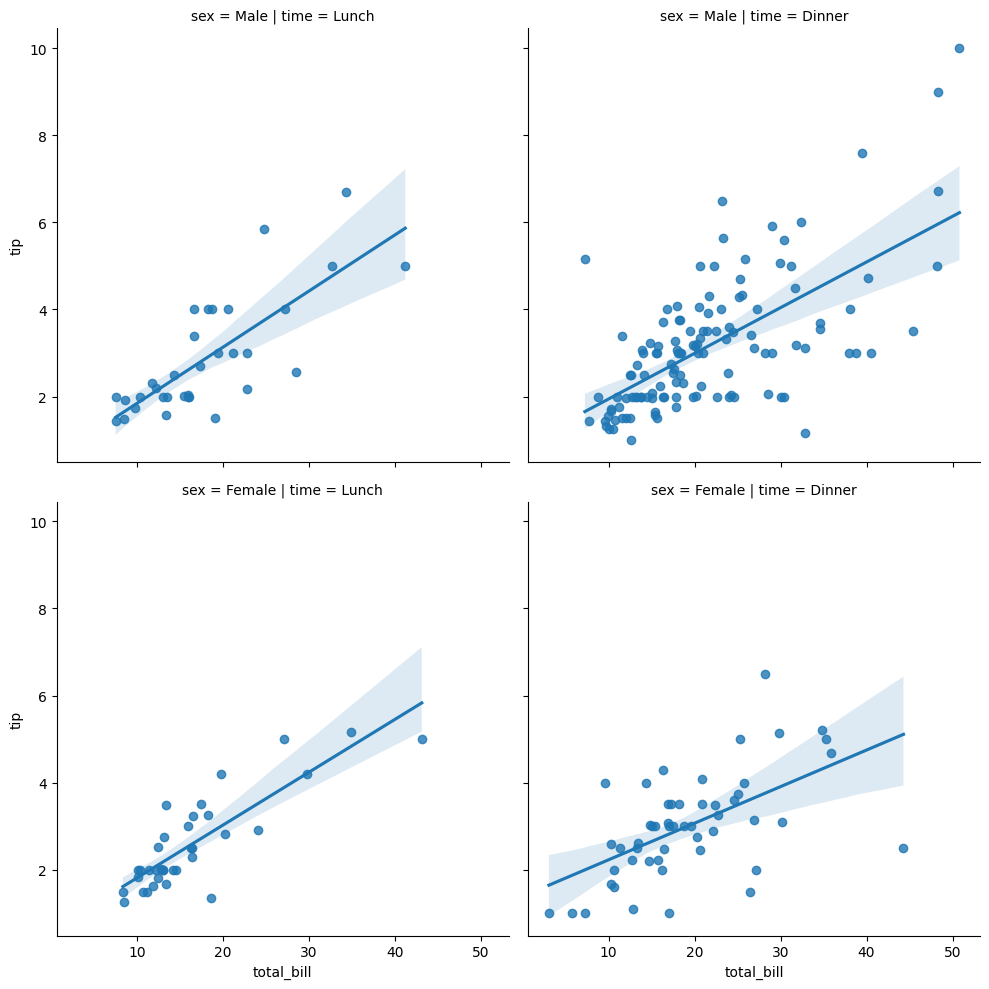

In [56]:
# row + col: 2x2 grid - facet by sex (rows) and time (columns)
sns.lmplot(x="total_bill", y="tip", row="sex", col="time",data=tips)

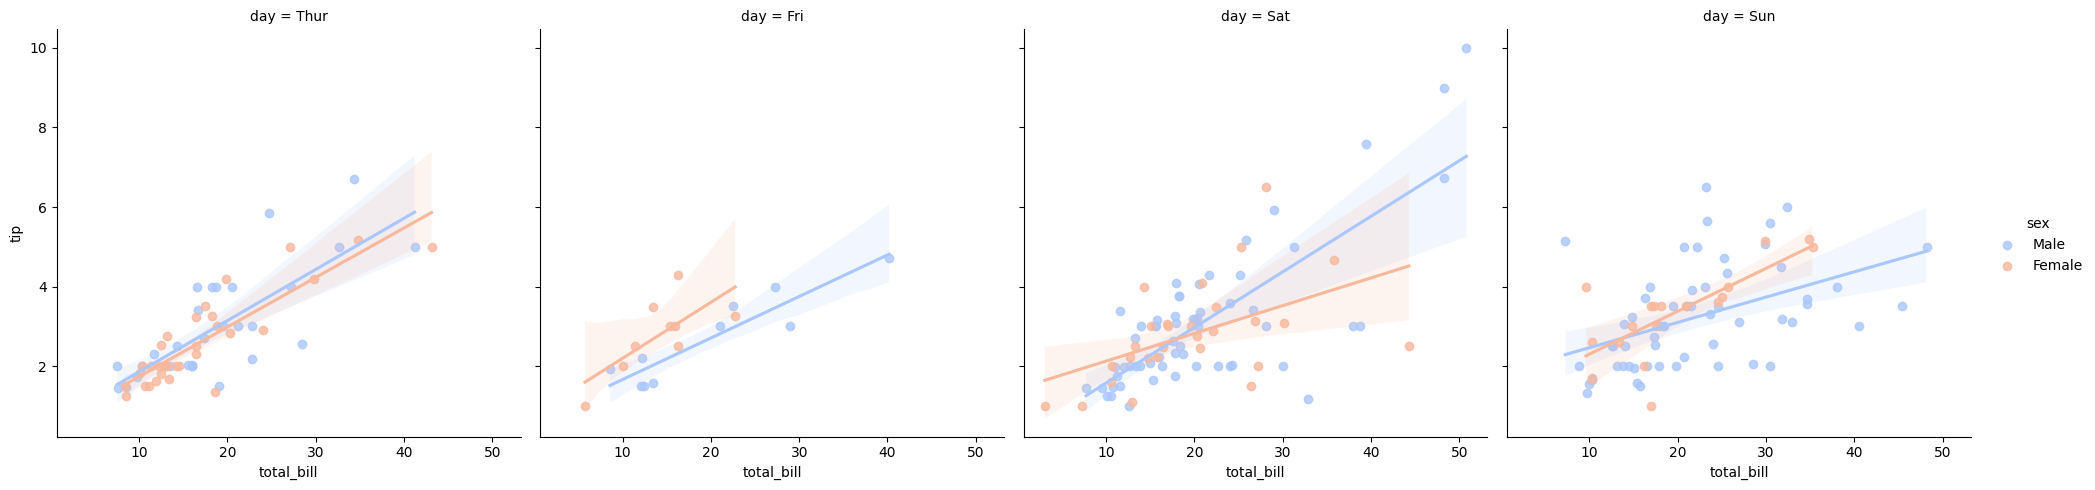

In [57]:
sns.lmplot(x='total_bill',y='tip',data=tips,col='day',hue='sex',palette='coolwarm')

## Aspect and Size

Seaborn figures can have their size and aspect ratio adjusted with the **height** and **aspect** parameters:

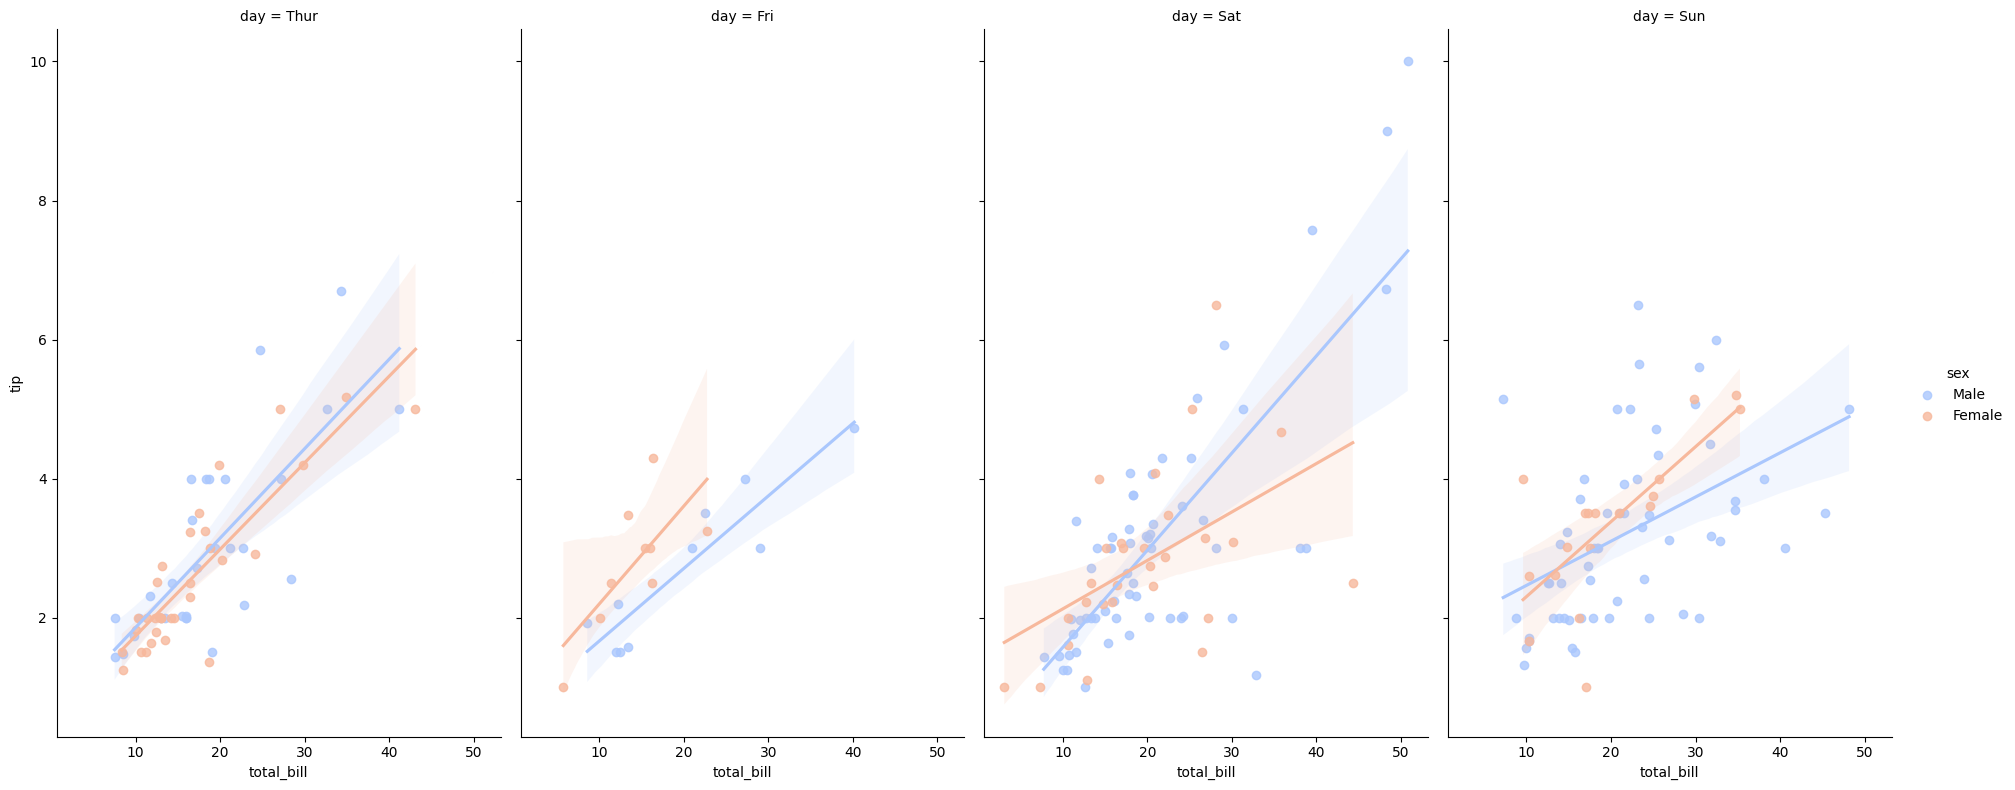

In [58]:
# aspect and height: control subplot dimensions - aspect=width/height ratio
sns.lmplot(x='total_bill',y='tip',data=tips,col='day',hue='sex',palette='coolwarm',
          aspect=0.6,height=8)

### Reference:

* https://seaborn.pydata.org/ - Seaborn: statistical data visualization


* https://seaborn.pydata.org/tutorial/color_palettes.html - Color palettes